## Regression Hyperparameters

| Hyperparameter       | Importance 💡 | Description |
|----------------------|---------------|-------------|
| **n_estimators**     | ⭐⭐⭐⭐         | Number of boosting rounds (trees). |
| **max_depth**        | ⭐⭐⭐⭐         | Maximum tree depth. |
| **learning_rate (eta)** | ⭐⭐⭐⭐     | Step size shrinkage. Low = better accuracy but slower. |
| **subsample**        | ⭐⭐⭐          | % of rows used per tree. |
| **colsample_bytree** | ⭐⭐⭐          | % of features used per tree. |
| **min_child_weight** | ⭐⭐           | Minimum sum of weights in a child. Helps avoid overfitting. |
| **gamma**            | ⭐⭐           | Minimum loss reduction required for a split. |
| **reg_alpha**        | ⭐⭐           | L1 regularization term. |
| **reg_lambda**       | ⭐⭐           | L2 regularization term. |

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [2]:
data = pd.read_csv("placement2.csv")

In [3]:
data

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
X = data.drop('package', axis=1)
y = data['package']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=4,
    eta=0.1,
    n_estimators=100,
    random_state=42
)


In [7]:
reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.1, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:
y_pred = reg.predict(X_test)

In [9]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.12330166525344737
R² Score: 0.667634316418849


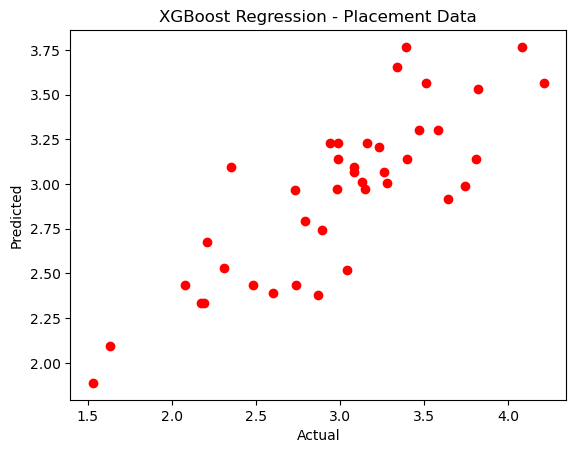

In [10]:
plt.scatter(y_test, y_pred, color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Regression - Placement Data")
plt.show()

In [18]:
param_grid_reg = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'min_child_weight': [1, 3],
    'reg_alpha': [0, 0.5],      
    'reg_lambda': [1, 2]         
}

In [19]:
reg = xgb.XGBRegressor(objective='reg:squarederror')

In [21]:
grid_r = GridSearchCV(
    estimator=reg,
    param_grid=param_grid_reg,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [22]:
grid_r.fit(X_train, y_train)

Fitting 3 folds for each of 512 candidates, totalling 1536 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 1],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'min_child_weight': [1, 3], 'n_estimators': [100, 150],
                         'reg_alpha': [0, 0.5], 'reg_lambda': [1, 2],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [23]:
print("Best Parameters (Regression):", grid_r.best_params_)

best = grid_r.best_estimator_
y_pred = best.predict(X_test)
print("MSE (Tuned):", mean_squared_error(y_test, y_pred))
print("R² Score (Tuned):", r2_score(y_test, y_pred))

Best Parameters (Regression): {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
MSE (Tuned): 0.09476751887568742
R² Score (Tuned): 0.7445495068727237
